# Time series analysis of Google Trends for "Fourier Transform"

In [1]:
#%pip install pytrends

In [2]:
#from pytrends.request import TrendReq
import pandas as pd

## Get Google trends data

In [3]:
#pytrends = TrendReq(hl='en-US', tz=360)

In [4]:
#keywords = ['Fourier Transform']
#pytrends.build_payload(keywords, cat=0, timeframe='all', geo='', gprop='')


Note the [maintainer stepped down](https://github.com/GeneralMills/pytrends/issues/636) and the repo is archived. They raise serious concerns about data quality but suggest trendspy as an alternative. Also I keep getting [error 429](https://stackoverflow.com/questions/50571317/pytrends-the-request-failed-google-returned-a-response-with-code-429)

In [5]:
trends_df=pd.read_csv('multiTimeline.csv',skiprows=2,parse_dates=[0]).set_index('Month')#pytrends.interest_over_time()


In [6]:
trends_df.dtypes

Fourier Transform: (Worldwide)    int64
dtype: object

<Axes: xlabel='Month'>

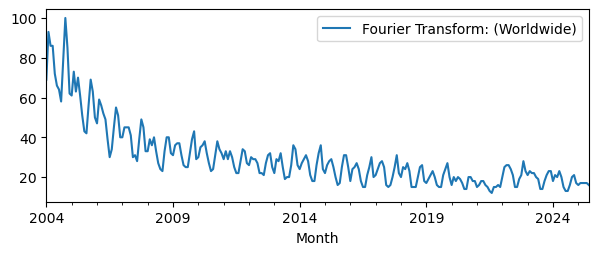

In [7]:
trends_df.plot(figsize=[7,2.5])

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

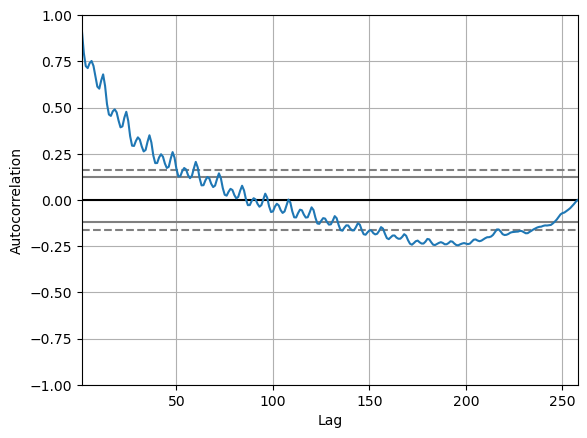

In [8]:
pd.plotting.autocorrelation_plot(trends_df)

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

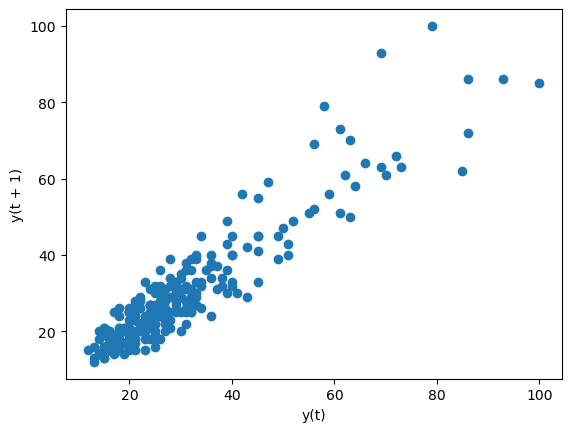

In [9]:
pd.plotting.lag_plot(trends_df,lag=1)

In [10]:
(trends_df
 .assign(Fourier_Transform_shifted_1m=trends_df
         .shift(periods=1)
        )
 .corr()
 .loc['Fourier_Transform_shifted_1m','Fourier Transform: (Worldwide)'] 
)

np.float64(0.9293125693134031)

In [11]:
trends_df['Fourier Transform: (Worldwide)'].autocorr(lag=1)

np.float64(0.9293125693134019)

Periodicity barely stands out in autocorrelation plot against decaying trend. A lag of 1 is the classic use of the lag plot as a test for randomness, as described in the NIST Engineering statistics handbook. In this case the data is definitely not random.

## Diff to remove slow decay, keep periodicity

In [12]:
def non_partial_diff(df):
    return (df
            .diff()
            .rename(columns={"Fourier Transform: (Worldwide)":"Google trend diff"})
            .dropna()
           )

<Axes: xlabel='Month'>

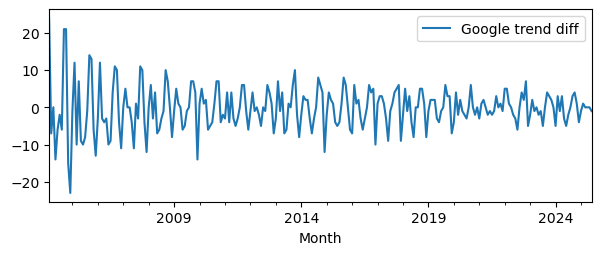

In [13]:
trends_df.pipe(non_partial_diff).plot(figsize=[7,2.5])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

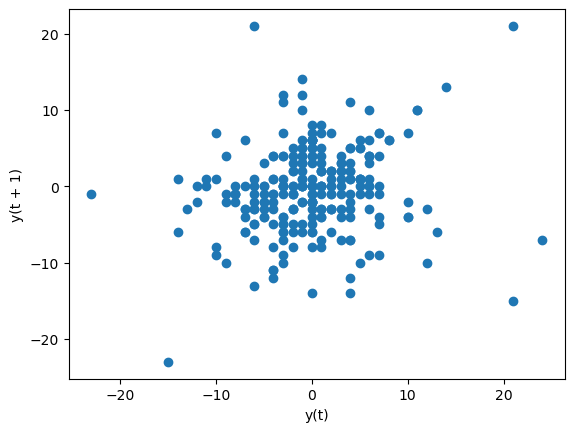

In [14]:
pd.plotting.lag_plot(trends_df.pipe(non_partial_diff),lag=1)

In [15]:
(trends_df
 .pipe(non_partial_diff)
 [['Google trend diff']]
 .assign(Google_trend_diff_shift_1m=trends_df
         .pipe(non_partial_diff)
         [['Google trend diff']]
         .shift(periods=1)
        )
 .corr()
 .loc['Google_trend_diff_shift_1m','Google trend diff']

)

np.float64(0.16995405644243025)

In [16]:
trends_df.pipe(non_partial_diff)['Google trend diff'].autocorr(lag=1)

np.float64(0.16995405644243017)

This time the lag 1 plot does show randomness.

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

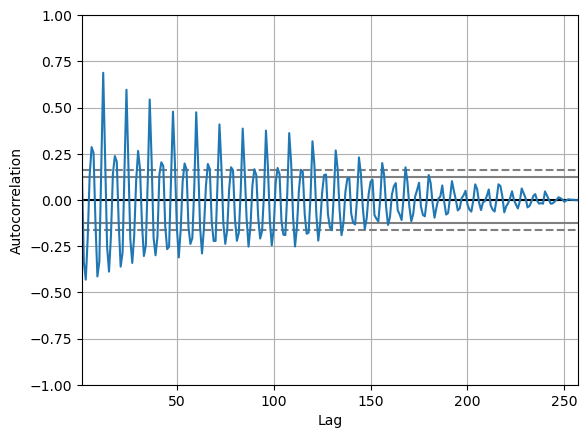

In [17]:
pd.plotting.autocorrelation_plot(trends_df.pipe(non_partial_diff))

Monthly data. High peaks: 12, 24, 36, 48... Smaller peaks half way through. 

<Axes: >

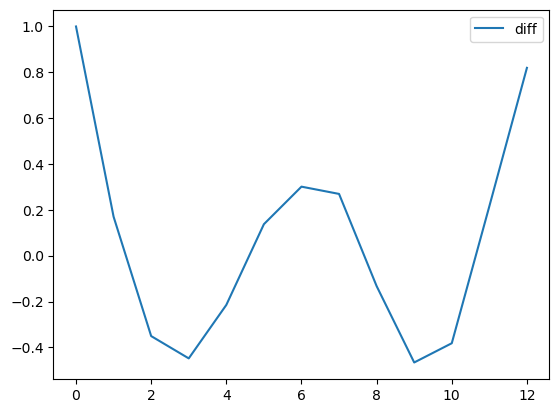

In [43]:
pd.DataFrame(
    [trends_df.pipe(non_partial_diff)['Google trend diff'].autocorr(n_index) for n_index in range(0,13,1) ]
).rename(columns={0:'diff'}).plot()

<Axes: xlabel='y(t)', ylabel='y(t + 12)'>

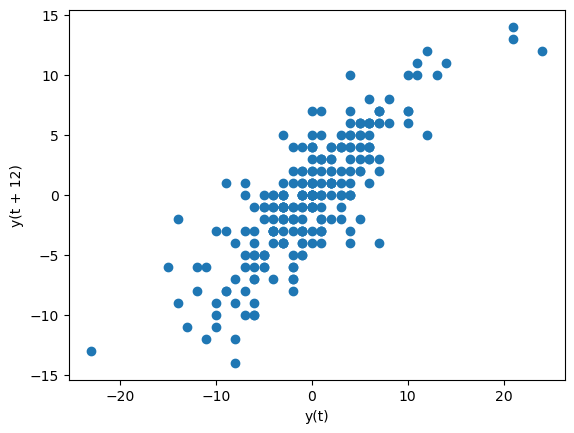

In [20]:
pd.plotting.lag_plot(trends_df.pipe(non_partial_diff),lag=12)

In [21]:
trends_df.pipe(non_partial_diff)['Google trend diff'].autocorr(lag=12)

np.float64(0.8195626269703368)

In [22]:
(trends_df
 .pipe(non_partial_diff)
 [['Google trend diff']]
 .assign(Google_trend_diff_shift_12m=trends_df
         .pipe(non_partial_diff)
         [['Google trend diff']]
         .shift(periods=12)
        )
 .corr()
 .loc['Google_trend_diff_shift_12m','Google trend diff']
)

np.float64(0.8195626269703371)

The lag plots for 12 and 6 months lag further confirm the relationship.

<Axes: xlabel='y(t)', ylabel='y(t + 6)'>

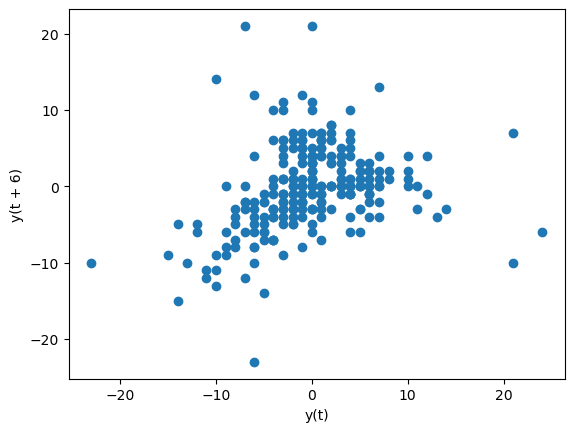

In [23]:
pd.plotting.lag_plot(trends_df.pipe(non_partial_diff),lag=6)

In [24]:
trends_df.pipe(non_partial_diff)['Google trend diff'].autocorr(lag=6)

np.float64(0.30112376919812994)

In [25]:
(trends_df
 .pipe(non_partial_diff)
 [['Google trend diff']]
 .assign(Google_trend_diff_shift_6m=trends_df
         .pipe(non_partial_diff)
         [['Google trend diff']]
         .shift(periods=6)
        )
 .corr()
 .loc['Google_trend_diff_shift_6m','Google trend diff']
)

np.float64(0.3011237691981302)

/tmp/ipykernel_2427/3179488680.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('12M')#ME on modern versions


<Axes: xlabel='Month'>

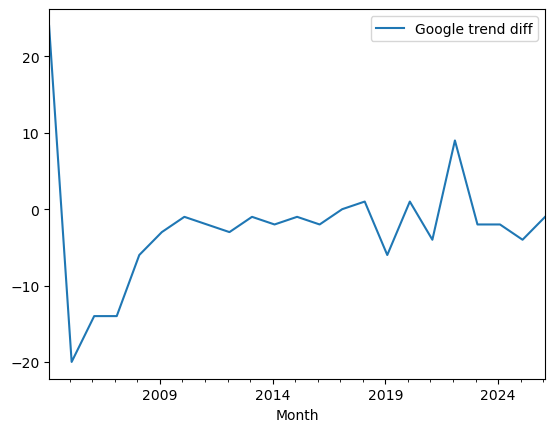

In [26]:
(trends_df
 .pipe(non_partial_diff)
 [['Google trend diff']]
 .resample('12M')#ME on modern versions
 .sum()
 .plot()
)

In [27]:
(trends_df
 .pipe(non_partial_diff)
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year
       )
 .query('year>2004 and year <=2014')
 .set_index(['yearless_month','year'])
  ['Google trend diff']
 .unstack()
 .corr()
 .style
 .background_gradient(cmap='RdBu', vmin=-1, vmax=1)
)


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
year,,,,,,,,,,
2005,1.000000,0.874619,0.847562,0.961582,0.766706,0.882790,0.967168,0.855984,0.902066,0.765559
2006,0.874619,1.000000,0.825975,0.838376,0.776077,0.838199,0.849106,0.855039,0.801729,0.784747
2007,0.847562,0.825975,1.000000,0.887583,0.856052,0.810847,0.839969,0.944901,0.895041,0.860321
2008,0.961582,0.838376,0.887583,1.000000,0.868113,0.876579,0.946778,0.918527,0.918705,0.865132
2009,0.766706,0.776077,0.856052,0.868113,1.000000,0.668780,0.793383,0.935935,0.850561,0.958076
2010,0.882790,0.838199,0.810847,0.876579,0.668780,1.000000,0.819208,0.730913,0.844828,0.679234
2011,0.967168,0.849106,0.839969,0.946778,0.793383,0.819208,1.000000,0.876053,0.914954,0.828323
2012,0.855984,0.855039,0.944901,0.918527,0.935935,0.730913,0.876053,1.000000,0.882184,0.932299
2013,0.902066,0.801729,0.895041,0.918705,0.850561,0.844828,0.914954,0.882184,1.000000,0.811839


Turn into cross correlation with a shift of N years: weighted sum of diagonal? Not really. Even if it was covariance matrix, cov(2005,2006)+cov(2006,2007) needs to be weighted itself?

In [28]:
(trends_df
 .pipe(non_partial_diff)
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year
       )
 .query('year>2004 and year <=2014')
 .set_index(['yearless_month','year'])
  ['Google trend diff']
 .unstack()
 .corr()
 .loc[2006,2005]
)

np.float64(0.8746193728860134)

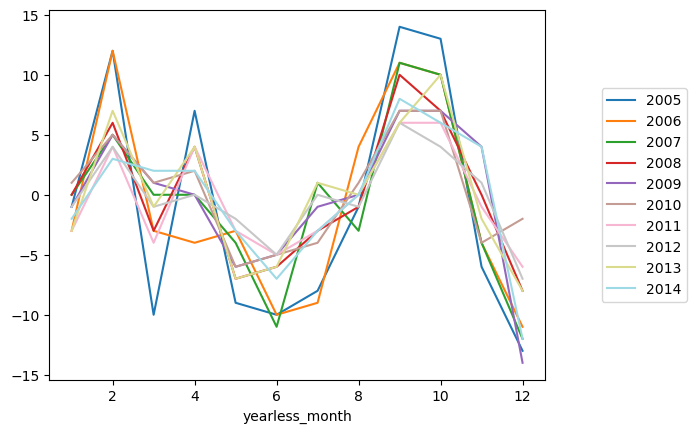

In [29]:
(trends_df
 .pipe(non_partial_diff)
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year,
         #covid19= lambda x: x['year'].ge(2020) & x['year'].le(2022)
         
       )
 .query('year>2004 and year <=2014')
 .set_index(['yearless_month','year'])#,'covid19'
  ['Google trend diff']
 .unstack()
 #.unstack()
 .dropna(how='all',axis='columns')
 .plot(cmap='tab20')
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)


In [30]:
(trends_df
 .pipe(non_partial_diff)
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year
       )
 .query('year>2014 and year <=2024')
 .set_index(['yearless_month','year'])
  ['Google trend diff']
 .unstack()
 .corr()
 .style
 .background_gradient(cmap='RdBu', vmin=-1, vmax=1)
)


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
year,,,,,,,,,,
2015,1.000000,0.864470,0.801882,0.883229,0.907599,0.671572,0.741999,0.651152,0.762235,0.863265
2016,0.864470,1.000000,0.841689,0.889626,0.916623,0.596909,0.753497,0.645485,0.665477,0.913762
2017,0.801882,0.841689,1.000000,0.880960,0.914105,0.253780,0.515064,0.769937,0.472620,0.747356
2018,0.883229,0.889626,0.880960,1.000000,0.906995,0.564494,0.537705,0.599799,0.540614,0.911867
2019,0.907599,0.916623,0.914105,0.906995,1.000000,0.489034,0.710626,0.707501,0.590935,0.824892
2020,0.671572,0.596909,0.253780,0.564494,0.489034,1.000000,0.662077,0.265794,0.714213,0.695099
2021,0.741999,0.753497,0.515064,0.537705,0.710626,0.662077,1.000000,0.460282,0.725243,0.675719
2022,0.651152,0.645485,0.769937,0.599799,0.707501,0.265794,0.460282,1.000000,0.635668,0.483151
2023,0.762235,0.665477,0.472620,0.540614,0.590935,0.714213,0.725243,0.635668,1.000000,0.705558


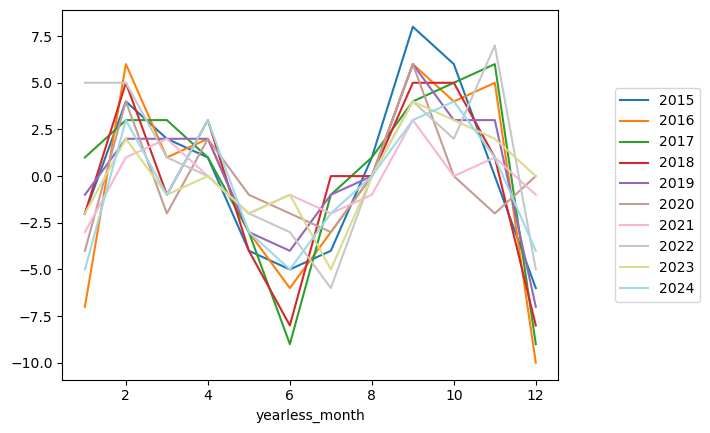

In [31]:
(trends_df
 .pipe(non_partial_diff)
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year,
         #covid19= lambda x: x['year'].ge(2020) & x['year'].le(2022)
         
       )
 .query('year>2014 and year <=2024')
 .set_index(['yearless_month','year'])#,'covid19'
  ['Google trend diff']
 .unstack()
 #.unstack()
 .dropna(how='all',axis='columns')
 .plot(cmap='tab20')
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)


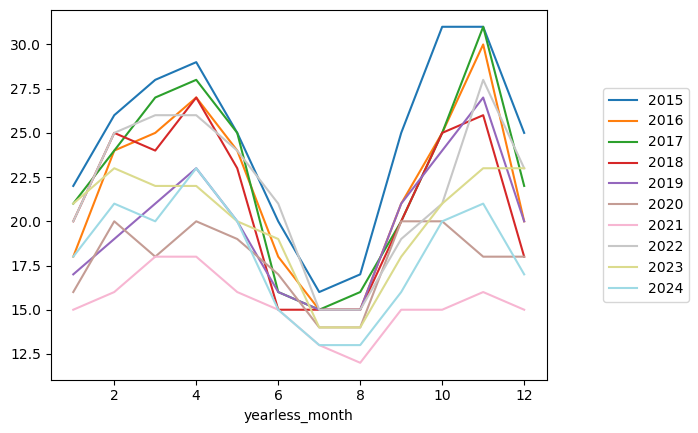

In [32]:
(trends_df
 #.pipe(non_partial_diff)
 .rename(columns={"Fourier Transform: (Worldwide)":"Google trend"})
 .reset_index()
 .assign(yearless_month= lambda x: x['Month'].dt.month,
         year=lambda x: x['Month'].dt.year
       )
 .query('year>2014 and year <=2024')
 .set_index(['yearless_month','year'])
  ['Google trend']
 .unstack()
 .dropna(how='all',axis='columns')
 .plot(cmap='tab20')
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

## diff to remove periodicity

<Axes: xlabel='Month'>

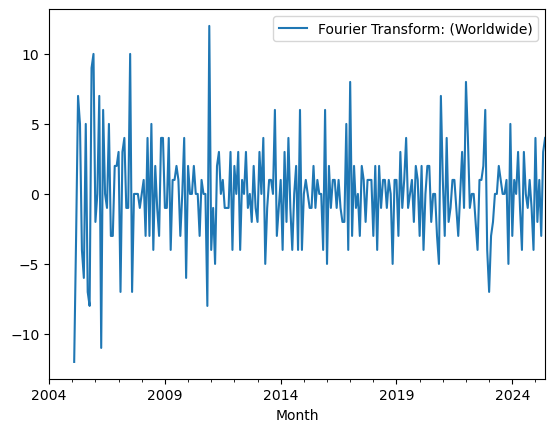

In [33]:
trends_df.diff().diff(periods=12).plot()

<Axes: xlabel='y(t)', ylabel='y(t + 12)'>

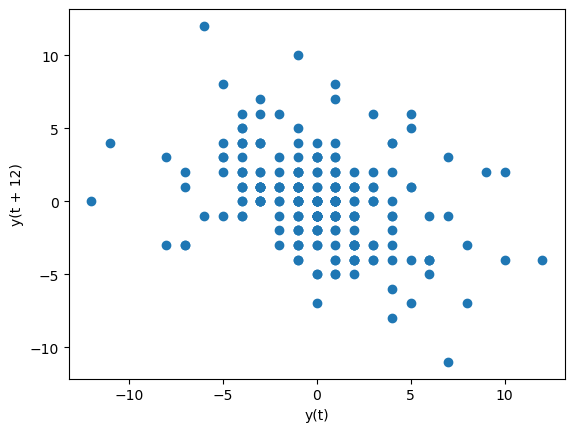

In [34]:
pd.plotting.lag_plot(trends_df.diff().diff(periods=12),lag=12)

In [35]:
trends_df.diff().diff(periods=12)['Fourier Transform: (Worldwide)'].autocorr(lag=12)

np.float64(-0.3629811010064811)

Inspired from a Linked In post by Kunpeng (KP) Liao. Released under the GPL 3.0 Licence.  
https://github.com/stelios-c/sig_proc/blob/main/timeseries.ipynb